In [1]:
# Import necessary libraries for data processing, visualization, and modeling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load training and testing datasets
X_train = pd.read_csv('Diabetes_XTrain.csv')
Y_train = pd.read_csv('Diabetes_YTrain.csv')
X_test = pd.read_csv('Diabetes_Xtest.csv')

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
X_train.head()

X_train shape: (576, 8)
Y_train shape: (576, 1)
X_test shape: (192, 8)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,7,168,88,42,321,38.2,0.787,40
1,8,110,76,0,0,27.8,0.237,58
2,7,147,76,0,0,39.4,0.257,43
3,2,100,66,20,90,32.9,0.867,28
4,4,129,86,20,270,35.1,0.231,23


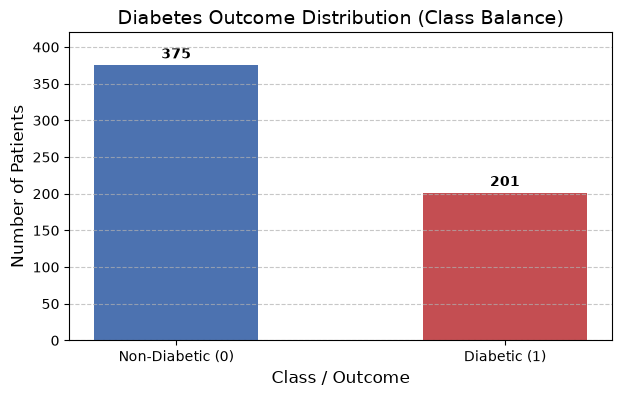

Class 0 (Non-Diabetic): 375 examples (65.1%)
Class 1 (Diabetic): 201 examples (34.9%)


In [3]:
# Task 1: Visualize class distribution of the target variable
classes, counts = np.unique(Y_train['Outcome'], return_counts=True)

plt.figure(figsize=(7, 4))
bars = plt.bar(['Non-Diabetic (0)', 'Diabetic (1)'], counts, color=['#4C72B0', '#C44E52'], width=0.5)

# Annotate bars with frequency counts
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f'{int(yval)}', ha='center', va='bottom', fontweight='bold')

plt.title('Diabetes Outcome Distribution (Class Balance)', fontsize=14)
plt.xlabel('Class / Outcome', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.ylim(0, 420)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Class 0 (Non-Diabetic): {counts[0]} examples ({counts[0]/len(Y_train)*100:.1f}%)")
print(f"Class 1 (Diabetic): {counts[1]} examples ({counts[1]/len(Y_train)*100:.1f}%)")

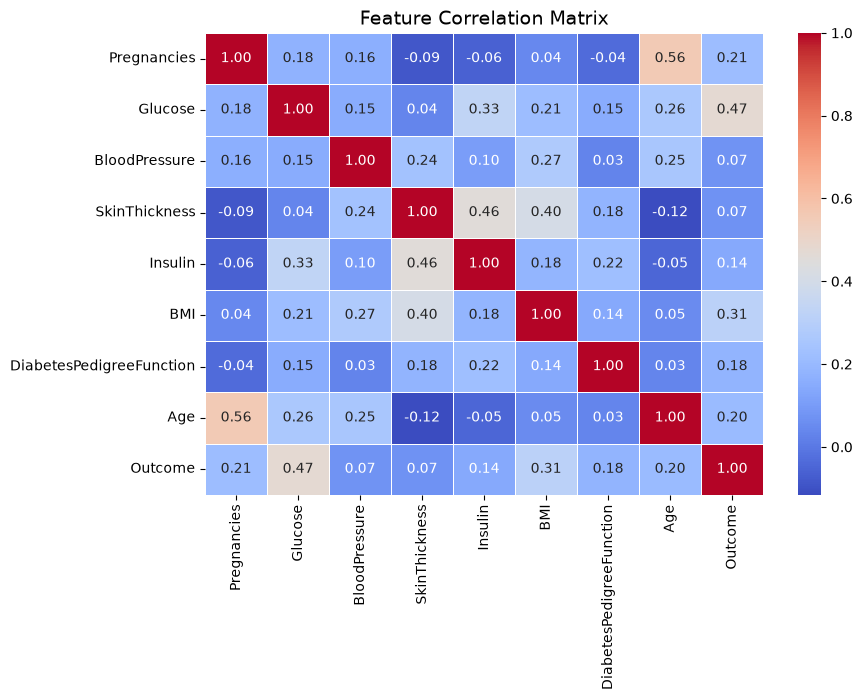

In [4]:
# Compute and visualize correlation matrix across features
combined_data = X_train.copy()
combined_data['Outcome'] = Y_train['Outcome']

plt.figure(figsize=(9, 6))
sns.heatmap(combined_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

Best K value: 15 with Cross-Validation Accuracy: 73.44%


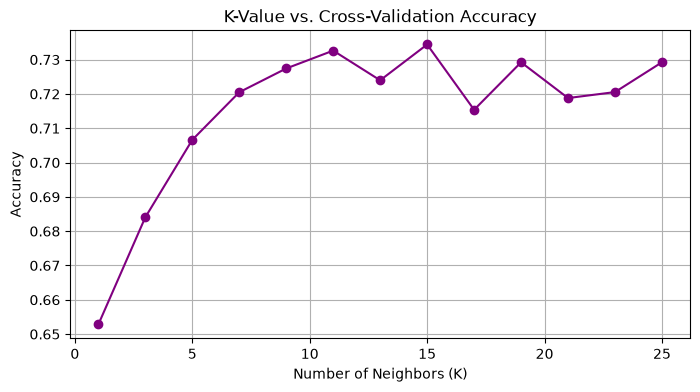

In [5]:
# Determine optimal k using 5-fold cross-validation
k_list = range(1, 26, 2)
cv_scores = []

for k in k_list:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train, Y_train.values.ravel(), cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_list[np.argmax(cv_scores)]
print(f"Best K value: {best_k} with Cross-Validation Accuracy: {max(cv_scores)*100:.2f}%")

# Plot K-value vs cross-validation accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_list, cv_scores, marker='o', color='purple')
plt.title('K-Value vs. Cross-Validation Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [6]:
# Task 2: Fit KNN classifier with optimal k
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, Y_train.values.ravel())

# Generate predictions on the test set
test_predictions = final_knn.predict(X_test)

# Export predictions to CSV format
output_df = pd.DataFrame(test_predictions, columns=['Outcome'])
output_df.to_csv('Diabetes_Predictions.csv', index=False)

print("Predictions successfully saved to 'Diabetes_Predictions.csv'!")
print(output_df.head(10))

Predictions successfully saved to 'Diabetes_Predictions.csv'!
   Outcome
0        0
1        0
2        0
3        0
4        0
5        0
6        1
7        0
8        0
9        0
